✅ Libraries loaded
Loaded 134,057 synthetic events
Traffic sources: ['organic' 'paid_search' 'social' 'direct' 'referral' 'email']

905 users made a purchase

📊 FIRST-TOUCH ATTRIBUTION:
traffic_source
organic        75415.55
paid_search    68936.38
social         52581.69
direct         40070.98
email           9658.64
referral        8712.42
Name: revenue, dtype: float64

📊 LAST-TOUCH ATTRIBUTION:
traffic_source
organic        74572.02
paid_search    65452.01
social         51800.66
direct         38945.43
referral       14741.90
email           9863.64
Name: revenue, dtype: float64

📊 LINEAR ATTRIBUTION:
traffic_source
organic        46786.377833
paid_search    46717.216333
social         46178.907000
direct         45541.223833
email          35700.779667
referral       34451.155333
Name: revenue, dtype: float64

📊 TIME-DECAY ATTRIBUTION:
traffic_source
organic        76218.080901
paid_search    65059.432440
social         49984.829931
direct         38221.178121
email          1297

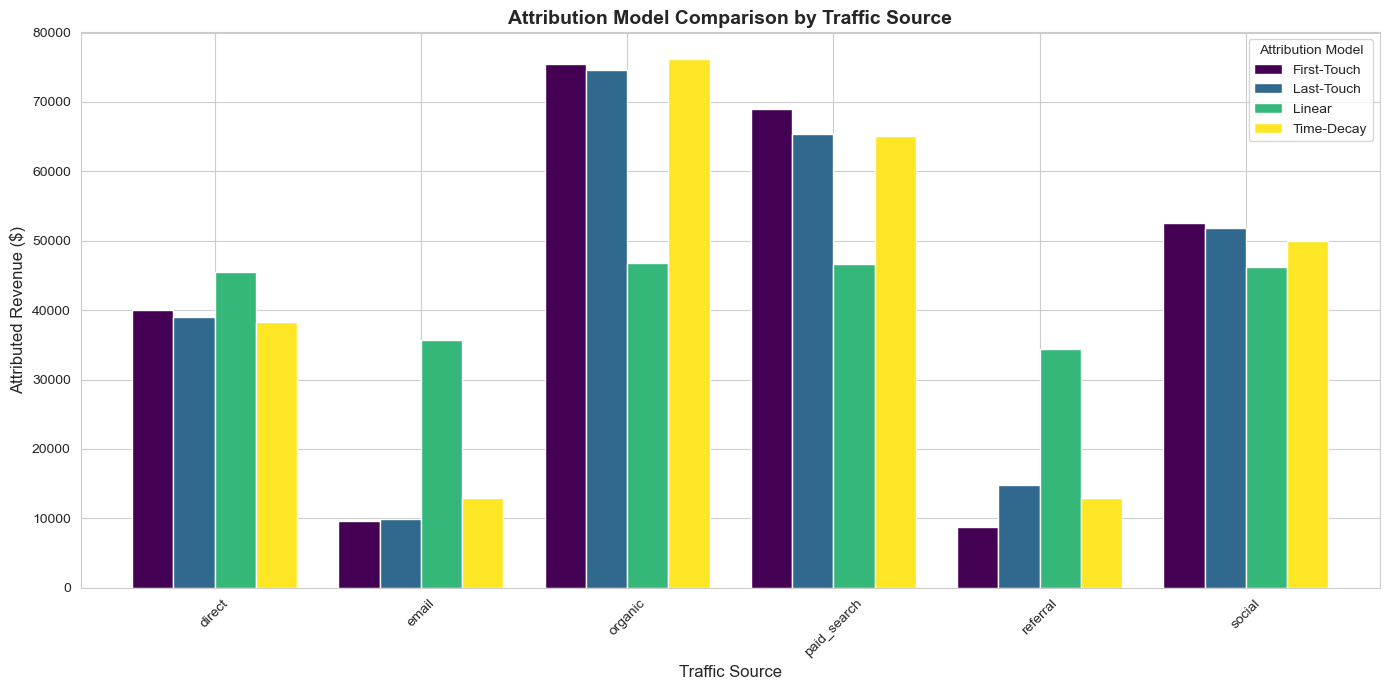

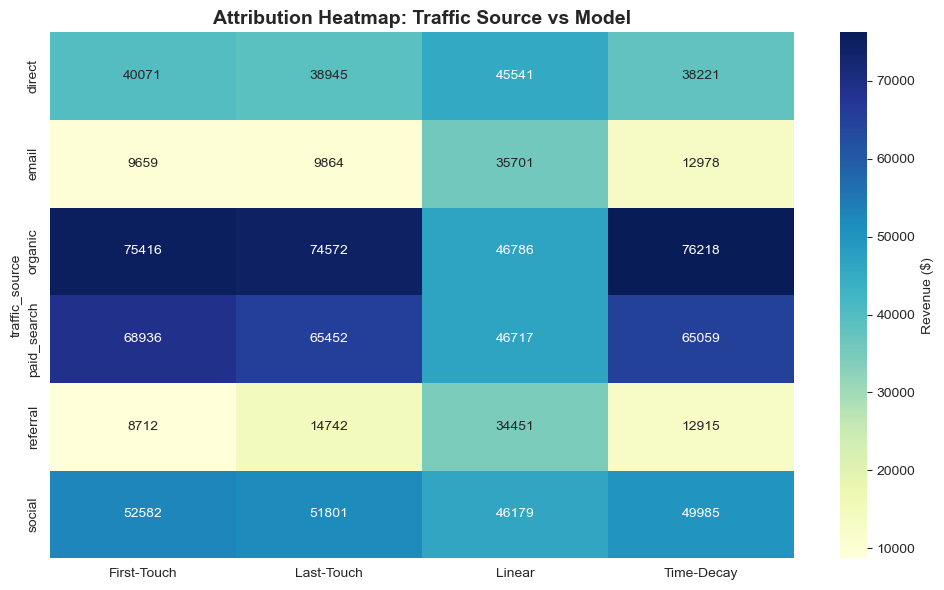


📊 ATTRIBUTION % OF TOTAL:
                First-Touch  Last-Touch  Linear  Time-Decay
traffic_source                                             
direct                 15.7        15.3    17.8        15.0
email                   3.8         3.9    14.0         5.1
organic                29.5        29.2    18.3        29.8
paid_search            27.0        25.6    18.3        25.5
referral                3.4         5.8    13.5         5.1
social                 20.6        20.3    18.1        19.6

✅ Attribution results saved to data/processed/
🎉 Day 7 complete!


In [1]:
# Day 7: Multi-Touch Attribution Modeling
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print("✅ Libraries loaded")

# ===== LOAD SYNTHETIC DATA (has traffic_source column) =====
df = pd.read_csv('../data/synthetic/synthetic_2025.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f"Loaded {len(df):,} synthetic events")
print(f"Traffic sources: {df['traffic_source'].unique()}")

# ===== FIND CONVERTED USERS AND THEIR JOURNEYS =====
purchased_users = df[df['event_type'] == 'purchase']['user_id'].unique()
print(f"\n{len(purchased_users):,} users made a purchase")

# Get full journey for purchased users (sorted by time)
journeys = df[df['user_id'].isin(purchased_users)].sort_values(['user_id', 'timestamp'])

# Get purchase amount for each purchase event
purchase_values = df[df['event_type'] == 'purchase'].groupby('user_id')['amount'].sum().to_dict()

# ===== ATTRIBUTION MODEL 1: FIRST-TOUCH =====
# 100% credit to the first traffic source
first_touch = journeys.groupby('user_id').first().reset_index()
first_touch['revenue'] = first_touch['user_id'].map(purchase_values)
first_touch_attribution = first_touch.groupby('traffic_source')['revenue'].sum().sort_values(ascending=False)
print("\n📊 FIRST-TOUCH ATTRIBUTION:")
print(first_touch_attribution)

# ===== ATTRIBUTION MODEL 2: LAST-TOUCH =====
# 100% credit to the last traffic source before purchase
last_touch = journeys.groupby('user_id').last().reset_index()
last_touch['revenue'] = last_touch['user_id'].map(purchase_values)
last_touch_attribution = last_touch.groupby('traffic_source')['revenue'].sum().sort_values(ascending=False)
print("\n📊 LAST-TOUCH ATTRIBUTION:")
print(last_touch_attribution)

# ===== ATTRIBUTION MODEL 3: LINEAR =====
# Equal credit to every traffic source in the journey
linear_records = []
for user_id in purchased_users:
    user_journey = journeys[journeys['user_id'] == user_id]
    unique_sources = user_journey['traffic_source'].unique()
    revenue_per_source = purchase_values.get(user_id, 0) / len(unique_sources)
    for source in unique_sources:
        linear_records.append({'traffic_source': source, 'revenue': revenue_per_source})

linear_df = pd.DataFrame(linear_records)
linear_attribution = linear_df.groupby('traffic_source')['revenue'].sum().sort_values(ascending=False)
print("\n📊 LINEAR ATTRIBUTION:")
print(linear_attribution)

# ===== ATTRIBUTION MODEL 4: TIME-DECAY =====
# More credit to touches closer to purchase (exponential decay)
time_decay_records = []
for user_id in purchased_users:
    user_journey = journeys[journeys['user_id'] == user_id].copy()
    purchase_time = user_journey[user_journey['event_type'] == 'purchase']['timestamp'].max()
    
    # Calculate days before purchase for each touch
    user_journey['days_before'] = (purchase_time - user_journey['timestamp']).dt.total_seconds() / 86400
    
    # Exponential decay: weight = 2^(-days/7) - half-life of 7 days
    user_journey['weight'] = 2 ** (-user_journey['days_before'] / 7)
    total_weight = user_journey['weight'].sum()
    
    if total_weight > 0:
        user_journey['credit'] = (user_journey['weight'] / total_weight) * purchase_values.get(user_id, 0)
        source_credits = user_journey.groupby('traffic_source')['credit'].sum()
        for source, credit in source_credits.items():
            time_decay_records.append({'traffic_source': source, 'revenue': credit})

time_decay_df = pd.DataFrame(time_decay_records)
time_decay_attribution = time_decay_df.groupby('traffic_source')['revenue'].sum().sort_values(ascending=False)
print("\n📊 TIME-DECAY ATTRIBUTION:")
print(time_decay_attribution)

# ===== COMBINE ALL MODELS FOR COMPARISON =====
comparison = pd.DataFrame({
    'First-Touch': first_touch_attribution,
    'Last-Touch': last_touch_attribution,
    'Linear': linear_attribution,
    'Time-Decay': time_decay_attribution
}).fillna(0)

print("\n📊 ATTRIBUTION COMPARISON (Revenue $):")
print(comparison.round(2))

# ===== VISUALIZE: SIDE-BY-SIDE COMPARISON =====
fig, ax = plt.subplots(figsize=(14, 7))
comparison.plot(kind='bar', ax=ax, colormap='viridis', width=0.8)
ax.set_title('Attribution Model Comparison by Traffic Source', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Traffic Source', fontsize=12)
ax.set_ylabel('Attributed Revenue ($)', fontsize=12)
ax.legend(title='Attribution Model', loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ===== VISUALIZE: HEATMAP =====
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(comparison, annot=True, fmt='.0f', cmap='YlGnBu', 
            cbar_kws={'label': 'Revenue ($)'}, ax=ax)
ax.set_title('Attribution Heatmap: Traffic Source vs Model', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ===== CALCULATE PERCENTAGE DIFFERENCES =====
pct_comparison = comparison.div(comparison.sum(axis=0), axis=1) * 100
print("\n📊 ATTRIBUTION % OF TOTAL:")
print(pct_comparison.round(1))

# ===== SAVE RESULTS =====
os.makedirs('../data/processed', exist_ok=True)
comparison.to_csv('../data/processed/attribution_comparison.csv')
pct_comparison.to_csv('../data/processed/attribution_percentages.csv')

print("\n✅ Attribution results saved to data/processed/")
print("🎉 Day 7 complete!")